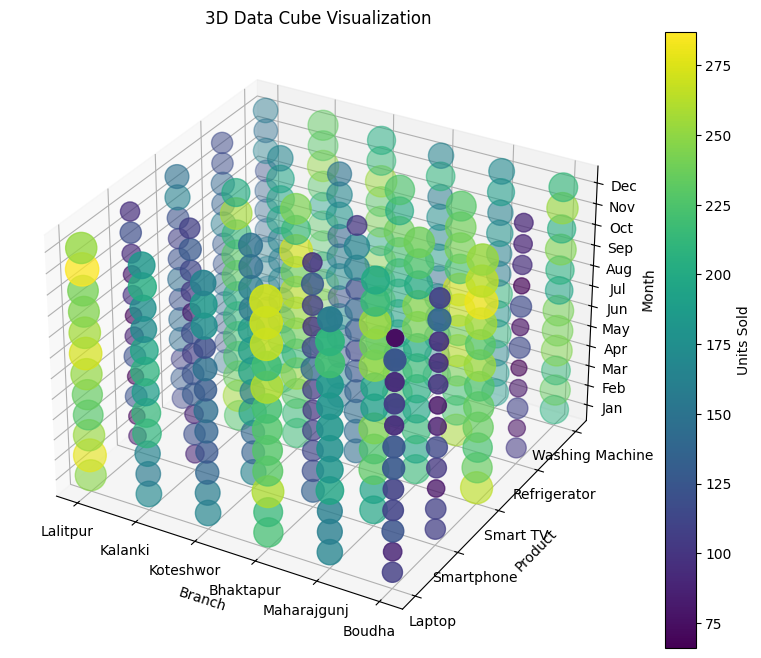

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("bhatbhateni.csv")

# Convert categorical values to numeric codes
df["Branch_Code"] = df["Branch"].astype("category").cat.codes
df["Product_Code"] = df["Product"].astype("category").cat.codes

month_order = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df["Month_Code"] = df["Month"].map(month_order)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Branch_Code"],
    df["Product_Code"],
    df["Month_Code"],
    s=df["Units_Sold"] * 2,
    c=df["Units_Sold"],
    cmap="viridis"
)

ax.set_xlabel("Branch")
ax.set_ylabel("Product")
ax.set_zlabel("Month")

# Display original labels
ax.set_xticks(df["Branch_Code"].unique())
ax.set_xticklabels(df["Branch"].astype("category").cat.categories)

ax.set_yticks(df["Product_Code"].unique())
ax.set_yticklabels(df["Product"].astype("category").cat.categories)

ax.set_zticks(range(1, 13))
ax.set_zticklabels([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

plt.colorbar(scatter, label="Units Sold")

plt.title("3D Data Cube Visualization")
plt.show()

In [1]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("bhatbhateni.csv")

month_order = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df["Month_Number"] = df["Month"].map(month_order)

fig = px.scatter_3d(
    df,
    x="Branch",
    y="Product",
    z="Month_Number",
    color="Units_Sold",
    size="Units_Sold",
    hover_data=["Revenue_NPR"],
    title="Interactive 3D OLAP Cube"
)

fig.show()